In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
#define a function to simulate the tissue curve with 1TCM
def cT_from_1TCM(k1,k2,times,input,unit_of_times):
    #here k1 and k2 are float numbers, times and input should be vectors of the same length, and unit_of_times is either 's' or 'min'
    #the units of k1 and k2 are assumed to be mL/min/mL and /min, respectively
    #the unit of the vector 'times' is specified by unit_of_times
    #the tissue curve cT will be in the same unit as the input
    #we first set the first value of cT as zero
    cT=[0]
    #then the rest of the cT values are obtained in an iterative loop
    for i in range(1,len(times)):
        if unit_of_times=='s':
            #we need the denominator 60 to since times are in seconds but K_1 and k_2 use /min
            cT.append(k1*(times[i]-times[i-1])/60*input[i-1]+
                (1-k2*(times[i]-times[i-1])/60)*cT[i-1])
        if unit_of_times=='min':
            #no denominator 60
            cT.append(k1*(times[i]-times[i-1])*input[i-1]+
                (1-k2*(times[i]-times[i-1]))*cT[i-1])
    return np.array(cT)

In [2]:
#define the midpoints of the original time frames in one dynamic 15O-water PET image in seconds with a zero added as the first value
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
#define the corresponding mean values of the tracer concentration in aorta (in Bq/mL)
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]
#create a function to interpolate the values for the input
interpolate_input = interpolate.interp1d(time, aorta)
#set new time points 0,1,...,265 s
times_interpolated = np.arange(0,266,1)
unit_of_times='s'
#produce cA with linear interpolation by `interp1d`
cA = interpolate_input(times_interpolated)

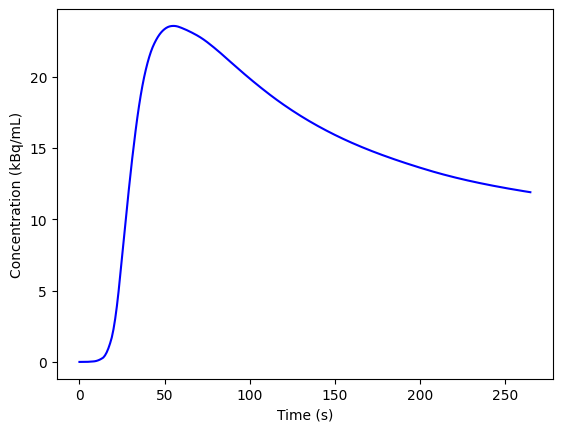

In [3]:
#simulate cT from any parameters (here K_1=0.9 and k_2=1)
cT=cT_from_1TCM(0.9,1,times_interpolated,cA,unit_of_times) #here, K_1=0.9 mL/min/mL and k_2=1/min
#plot the tissue curve cT (converted here into kBq/mL by dividing it by 1000)
plt.plot(times_interpolated, cT/1000, '-b')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (kBq/mL)')
plt.show()

In [4]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
left_ventricle=[0,591,22556,104839,85805,77595,54018,38902,3375,
    28872,28720,26316,23821,23311,27377,21921,20258,
    20934,18856,18351,17096,15520,15054,14202,13479]

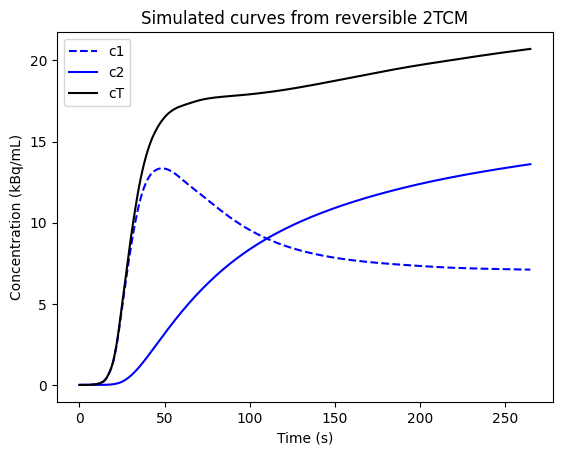

K_1a: 0.31886083840385787
k_2a: 0.15470131397065667
K_1b: 0.2811391615961421
k_2b: 1.7452986860293436


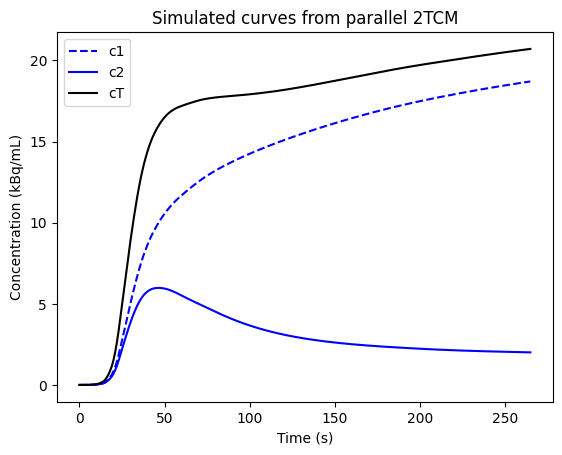

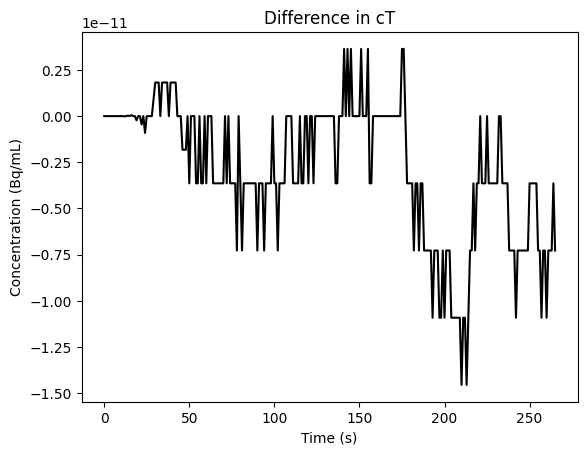

In [5]:
#run first the previous codes about 1TCM to import libraries and initialise times_interpolated, unit_of_times, and cA
#define a function to simulate the tissue curve with a reversible 2TCM
def cT_from_reversible_2TCM(k1,k2,k3,k4,times,input,unit_of_times):
    #here k1,k2,k3,k4 are float numbers, and times and input should be vectors of the same length, unit_of_times is either 's' or 'min' 
    #the units of k1,k2,k3,k4 are assumed to be mL/min/mL, /min, /min, and /min
    #the unit of times is specified by unit_of_times
    #the first value of c1 and c2 are set as zero
    c1=[0]
    c2=[0]
    #then the rest of the values of c1 and c2 are obtained in an iterative loop
    for i in range(1,len(times)):
        if unit_of_times=='s':
            #we need the denominator 60 to since times are in seconds but k_is use /min
            c1.append(c1[i-1]+(times[i]-times[i-1])/60*(k1*input[i-1]-
                (k2+k3)*c1[i-1]+k4*c2[i-1]))
            c2.append(c2[i-1]+(times[i]-times[i-1])/60*(k3*c1[i-1]-
                k4*c2[i-1]))
        if unit_of_times=='min':
            #no denominator 60
            c1.append(c1[i-1]+(times[i]-times[i-1])*(k1*input[i-1]-
                (k2+k3)*c1[i-1]+k4*c2[i-1]))
            c2.append(c2[i-1]+(times[i]-times[i-1])*(k3*c1[i-1]-
                k4*c2[i-1]))
    c1=np.array(c1)
    c2=np.array(c2)
    cT=c1+c2   
    return c1,c2,cT
#define a function to simulate the tissue curve with a parallel 2TCM
def cT_from_parallel_2TCM(k1a,k2a,k1b,k2b,times,input,unit_of_times):
    #here k1,k2,k3,k4 are float numbers, and times and input should be vectors of the same length, unit_of_times is either 's' or 'min' 
    #the units of k1,k2,k3,k4 are assumed to be mL/min/mL, /min, /min, and /min
    #the unit of times is specified by unitOfTimes
    #the first value of c1 and c2 are set as zero
    c1=[0]
    c2=[0]
    #then the rest of the values of c1 and c2 are obtained in an iterative loop
    for i in range(1,len(times)):
        if unit_of_times=='s':
            #we need the denominator 60 to since times are in seconds but k_is use /min
            c1.append(c1[i-1]+(times[i]-times[i-1])/60*(k1a*input[i-1]-
                k2a*c1[i-1]))
            c2.append(c2[i-1]+(times[i]-times[i-1])/60*(k1b*input[i-1]-
                k2b*c2[i-1]))
        if unit_of_times=='min':
            #no denominator 60
            c1.append(c1[i-1]+(times[i]-times[i-1])*(k2a*input[i-1]-
                k2a*c1[i-1]))
            c2.append(c2[i-1]+(times[i]-times[i-1])*(k2b*input[i-1]-
                k2b*c2[i-1]))
    c1=np.array(c1)
    c2=np.array(c2)
    cT=c1+c2  
    return c1,c2,cT
#choose some rate constant for the reversible 2TCM
k1=0.6
k2=0.9
k3=0.7
k4=0.3
#simulate the curves c1,c2,cT from the reversible 2TCM
c1_rvb,c2_rvb,cT_rvb=cT_from_reversible_2TCM(k1,k2,k3,k4,times_interpolated,cA,
    unit_of_times)
#plot the result in kBq/mL
plt.plot(times_interpolated,c1_rvb/1000,'--b',times_interpolated,c2_rvb/1000,'-b',
    times_interpolated,cT_rvb/1000,'-k')
plt.legend(['c1','c2','cT'])
plt.xlabel('Time (s)')
plt.ylabel('Concentration (kBq/mL)')
plt.title('Simulated curves from reversible 2TCM')
plt.show()
#choose rate constants for the parallel 2TCM so that the output should be the same as from the reversible 2TCM
k2a=1/2*(k2+k3+k4-((k2+k3+k4)**2-4*k2*k4)**0.5)
k2b=1/2*(k2+k3+k4+((k2+k3+k4)**2-4*k2*k4)**0.5)
k1a=k1/(k2b-k2a)*(k3+k4-k2a)
k1b=k1/(k2b-k2a)*(k2b-k3-k4)
#print these choices
print('K_1a:',k1a)
print('k_2a:',k2a)
print('K_1b:',k1b)
print('k_2b:',k2b)
#simulate the tissue curve cT from the parallel 2TCM
c1_prl,c2_prl,cT_prl=cT_from_parallel_2TCM(k1a,k2a,k1b,k2b,times_interpolated,
    cA,unit_of_times)
#plot the result
plt.plot(times_interpolated,c1_prl/1000,'--b',times_interpolated,c2_prl/1000,'-b',
    times_interpolated,cT_prl/1000,'-k')
plt.legend(['c1','c2','cT'])
plt.xlabel('Time (s)')
plt.ylabel('Concentration (kBq/mL)')
plt.title('Simulated curves from parallel 2TCM')
plt.show()
#plot the difference between cT curves (here in Bq/mL)
plt.plot(times_interpolated,cT_rvb-cT_prl,'-k')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (Bq/mL)')
plt.title('Difference in cT')
plt.show()

In [6]:
time=[0,30,75,105,135,165,195,225,270,450,750,1050,1500,
    2100,2800]
aorta=[0,8987,4469,4178,4450,3510,2492,4043,3733,2918,2996,2385,2250,
    1987,1600]

In [7]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]

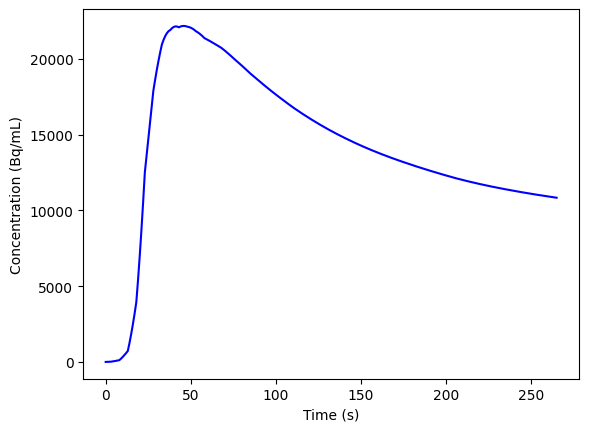

In [8]:
#import libraries and define times_interpolated and cA as in the previous codes of this chapter
#cA is the (interpolated) AIF
#cT is the concentration in the tissue simulated from 1TCM, 2TCM, or some other model
alpha=0.9
V_a=0.1
cPET=alpha*(1-V_a)*cT+V_a*cA
plt.plot(times_interpolated, cPET, '-b')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (Bq/mL)')
plt.show()

In [9]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]

In [10]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]
left_ventricle=[0,591,22556,104839,85805,77595,54018,38902,3375,
    28872,28720,26316,23821,23311,27377,21921,20258,
    20934,18856,18351,17096,15520,15054,14202,13479]

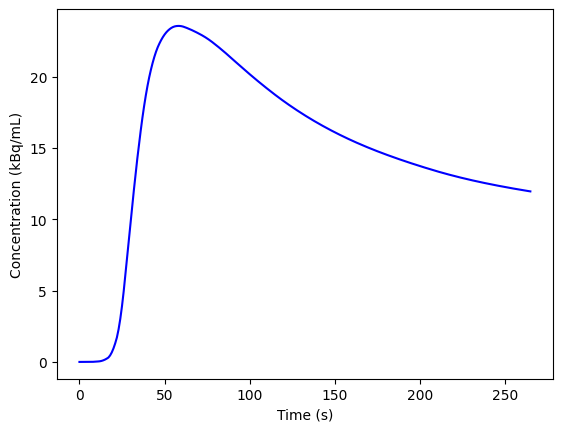

In [11]:
#run first the codes about 1TCM to import libraries and initialise times_interpolated, unit_of_times, and cA
from scipy import interpolate
#define an extended version of the interpolation function to avoid 'out-of-range' errors
def interpolate_extended(t,x,y):
    #if the point is on the interval, interpolate normally
    if x[0]<t<x[-1]:
         interpolate_1=interpolate.interp1d(x,y)
         return(interpolate_1(t))
    #if the point is before the interval, return the value at the first point of the interval
    elif t<=x[0]:
        return(y[0])
    #if the point after the interval, return the value at the last point of the interval
    else:
        return(y[-1])
#define a function to simulate the tissue curve with 1TCM with delay
def cT_from_1TCM_with_delay(k1,k2,times,input,delay,unit_of_times, unit_of_delay):
    #here k1,k2, and delay are float numbers, times and input should be vectors of the same length, and unit_of_times and unit_of_delay are 's' or 'min'
    #the units of k1 and k2 are assumed to be mL/min/mL and /min, respectively
    #the unit of times and delay are specified by unit_of_times and unit_of_delay
    #the first value of cT is set as zero
    cT=[0]
    #then the rest of the cT values are obtained in an iterative loop
    for i in range(1,len(times)):
        #let us define the value of input at time[i-1]-delay
        if unit_of_times==unit_of_delay:
            input_value=interpolate_extended(times[i-1]-delay,times,input)
        if unit_of_times=='min' and unit_of_delay=='s':
            input_value=interpolate_extended(times[i-1]-(1/60)*delay,times, input)
        if unit_of_times=='s' and unit_of_delay=='min':
            input_value=interpolate_extended(times[i-1]-60*delay,times,input)
        #let us append the current value of cT
        if unit_of_times=='s':
            cT.append(k1*(times[i]-times[i-1])/60*input_value
                +(1-k2*(times[i]-times[i-1])/60)*cT[i-1])
        if unit_of_times=='min':
            cT.append(k1*(times[i]-times[i-1])*input_value
                +(1-k2*(times[i]-times[i-1]))*cT[i-1])
    return np.array(cT)
#simulate cT from any parameters
unit_of_delay='s'
cT=cT_from_1TCM_with_delay(0.9,1,times_interpolated,cA,3,unit_of_times,unit_of_delay) #here, K_1=0.9 mL/min/mL and k_2=1/min and delay is 3 seconds
#plot the resulting tissue curve (here scaled into kBq/mL)
plt.plot(times_interpolated, cT/1000, '-b')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (kBq/mL)')
plt.show()

In [12]:
time=[0,3,8,13,18,23,28,33,38,43,48,53,58,63,68,75,85,95,
    110,130,150,175,205,235,265]
left_ventricle=[0,591,22556,104839,85805,77595,54018,38902,3375,
    28872,28720,26316,23821,23311,27377,21921,20258,
    20934,18856,18351,17096,15520,15054,14202,13479]

In [13]:
time=[0,3,8,13,18,23,28,33,38,43,48,53,58,63,68,75,85,95,
    110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]

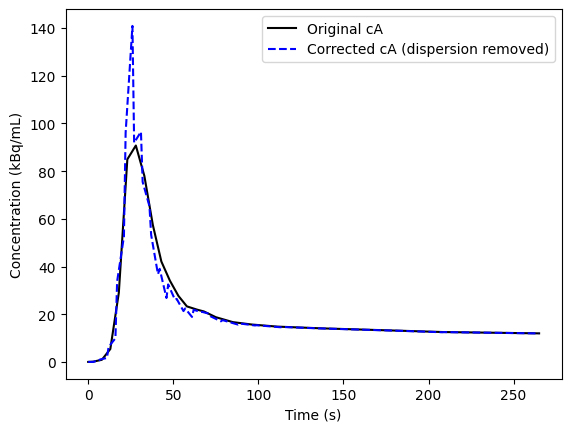

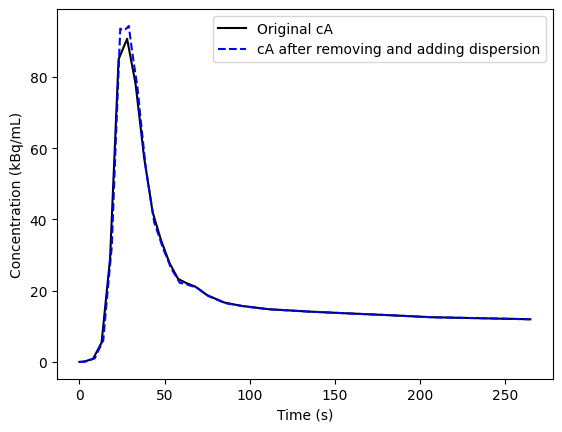

In [15]:
#run first the previous code about 1TCM and the code about time delay to import libraries and initialise times_interpolated, cA, interpolate_extended, and cT_from_1TCM_with_delay
#define a function for a typical dispersion correction that removes dispersion from the input
def remove_dispersion(times,input,tau,delay):
    #times and input are vectors of the same length, tau an delay are float numbers
    #the unit of times, tau, and delay is assumed to be in seconds
    corrected_input=[0]
    for i in range(1,len(times)):
        if delay==0:
            #if there is delay, the formula is very simple
            corrected_input.append(input[i]+tau*(input[i]-input[i-1])/(
                times[i]-times[i-1]))
        else:
            #if there is delay, we need to use interpolation to obtain the values at times[i]-delay and times[i-1]-delay
            delayed_input_i=interpolate_extended(times[i]-delay,times,
                input)
            delayed_input_i1=interpolate_extended(times[i-1]-delay,times,
                input)
            corrected_input.append(delayed_input_i+tau*(delayed_input_i
            -delayed_input_i1)/(times[i]-times[i-1]))
    return(np.array(corrected_input))
#define a function for an 'inverse' dispersion correction that adds dispersion to the input
def add_dispersion(times,input,tau,delay):
    #times and input are vectors of the same length, tau an delay are float numbers
    #the unit of times, tau, and delay is assumed to be in seconds
    #to remove dispersion, we use 1TCM
    #we need to choose K1 and k2 so that they correspond 1/tau if the time unit is the same
    #in other words, we fix K1=k2=1/(tau/60) since the unit of K1 and k2 is /min and tau is in seconds
    return(cT_from_1TCM_with_delay(1/(tau/60),1/(tau/60),times,input,
        delay,'s','s'))
#let the dispersion constant be 5 seconds and delay 3 seconds
tau=5
delay=3
#perform the dispersion correction for cA with the assumption that cA is the measured curve g from blood sampling and we want its dispersion-corrected version to estimate the real tracer concentration in the blood
cA_corrected=remove_dispersion(times_interpolated,cA,tau,delay)
#plot the cA before and after dispersion correction (here converted into kBq/mL)
plt.plot(times_interpolated,cA/1000,'-k',times_interpolated,
cA_corrected/1000,'--b')
plt.legend(['Original cA','Corrected cA (dispersion removed)'])
plt.xlabel('Time (s)')
plt.ylabel('Concentration (kBq/mL)')
plt.show()
#now, add dispersion to cA_real and remove the delay 
#delay is removed by adding a minus sign below
cA_new=add_dispersion(times_interpolated,cA_corrected,tau,-delay)
#compare the original cA and the new cA obtained after removing and adding dispersion
plt.plot(times_interpolated,cA/1000,'-k',times_interpolated,cA_new/1000,'--b')
plt.legend(['Original cA','cA after removing and adding dispersion'])
plt.xlabel('Time (s)')
plt.ylabel('Concentration (kBq/mL)')
plt.show()

In [16]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
left_ventricle=[0,591,22556,104839,85805,77595,54018,38902,3375,
    28872,28720,26316,23821,23311,27377,21921,20258,
    20934,18856,18351,17096,15520,15054,14202,13479]

In [17]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]

Sum of squares: 989049.1864520882


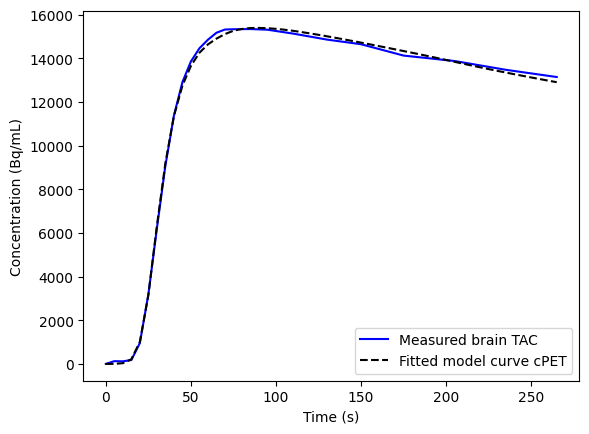

In [18]:
#run the previous codes of this chapter to initialize interpolate_extended and cT_from_1TCM_with_delay
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy import optimize
import math
#initiliaze the time points
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
times_interpolated = np.arange(0,266,5)
unit_of_times='s'
unit_of_delay='s'
#initilize the input
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]
interpolate_input = interpolate.interp1d(time, aorta)
cA = interpolate_input(times_interpolated)
#initilize the tissue TAC 
# (the vector 'brain' is the mean values of the tracer concentration in 
# brain in the original time frames (in Bq/mL))
brain=[0,131,120,116,271,1984,4982,8035,10641,
    12466,13561,14294,14700,15073,15312,15330,15338,
    15308,15131,14855,14643,14123,13874,13473,13141]
interpolate_TAC = interpolate.interp1d(time, brain)
measured_TAC=interpolate_TAC(times_interpolated)
#define an error function computing the sum of squares between the measured TAC and the model curve cPET
def error_function(param):
    #param is a list of four numeric values
    #simulate cT and then cPET from the parameters in the param vector
    #use absolute value for param[0] and param[1] since k1 and k2 should be non-negative
    cT=cT_from_1TCM_with_delay(abs(param[0]),abs(param[1]),times_interpolated,
    cA,param[3],unit_of_times,unit_of_delay)
    #use inverse-logit for param[2] as V_a is between 0 and 1
    V_a=1/(1+math.exp(-param[2]))
    cPET=(1-V_a)*cT+V_a*cA
    #compute and return the sum of squares between the measured TAC and cPET
    sum_of_squares=np.sum((measured_TAC-cPET)**2)
    return sum_of_squares
#choose initial values (here, param[2] is chosen so that V_a=0.1 after the inverse-logit transformation)
initial_values=[1,1,math.log(9),0]
#minimise the output of the error function
res=optimize.minimize(error_function,x0=initial_values)
#print the found minimum sum of squares
print('Sum of squares:',res.fun)
#fix k1,k2,V_a and delay to the values giving this minimum
k1=abs(res.x[0])
k2=abs(res.x[1])
V_a=1/(1+math.exp(-res.x[2]))
delay=res.x[3]
#simulate the cT and cPET from the found solution
cT=cT_from_1TCM_with_delay(k1,k2,times_interpolated,cA,delay,'s','s')
cPET=(1-V_a)*cT+V_a*cA
#plot the fitted model curve together with the measured TAC
plt.plot(times_interpolated,measured_TAC,'-b',times_interpolated,cPET,'--k')
plt.legend(['Measured brain TAC','Fitted model curve cPET'])
plt.xlabel('Time (s)')
plt.ylabel('Concentration (Bq/mL)')
plt.show()

In [19]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]
thyroid_gland=[0,199,157,490,2157,16156,25362,32572,37662,
    33655,33734,29877,25350,23721,22939,17890,15598,
    15111,13479,11646,10930,10138,10167,10048,9923]

In [20]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]
brain=[0,131,120,116,271,1984,4982,8035,10641,
    12466,13561,14294,14700,15073,15312,15330,15338,
    15308,15131,14855,14643,14123,13874,13473,13141]

In [21]:
time=[0,3,8,13,18,23,28,33,38,
    43,48,53,58,63,68,75,85,
    95,110,130,150,175,205,235,265]
aorta=[0,124,886,5406,29009,84960,90750,78030,57405,
    42104,34094,27709,23290,22109,21168,18760,16693,
    15754,14843,14245,13780,13292,12567,12291,11974]
kidney=[0,30,63,114,1208,9420,9420,22377,30467,
    34942,36467,30329,25564,25664,26808,20579,17790,
    16638,14134,13163,12187,11746,11500,11404,11249]